# 04 — Modelo: Rede Neural

Implementação do modelo de Rede Neural com Keras/TensorFlow.

**Etapas obrigatórias (conforme projeto da disciplina):**
1. Definir arquitetura via dimensão VC e Regra de Ouro
2. Computar E_in e E_out para analisar overfitting
3. Identificar a partir de qual época ocorreu overfitting (se houve)
4. Justificar batch size e número de épocas
5. Computar métricas de qualidade (acurácia, precisão, recall, F1)

In [1]:
import sys, os
sys.path.insert(0, '..')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.models import (
    compute_vc_dimension,
    golden_rule_check,
    build_neural_network,
    train_neural_network,
)
from src.evaluation import (
    compute_metrics,
    compute_ein_eout,
    plot_overfitting_curve,
    plot_confusion_matrix,
    print_classification_report,
)
from src.utils import save_model, FIGURES_DIR, DATA_PROCESSED

%matplotlib inline

In [2]:
X_train = np.load(DATA_PROCESSED / 'X_train.npy')
X_test  = np.load(DATA_PROCESSED / 'X_test.npy')
y_train = np.load(DATA_PROCESSED / 'y_train.npy')
y_test  = np.load(DATA_PROCESSED / 'y_test.npy')

# Separar validação interna do treino (20% do treino → ~891 amostras)
# O conjunto de teste permanece intocado até o notebook 07
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

N, p = X_train.shape
print(f"Treino total:       {len(X_train)} amostras")
print(f"  Treino efetivo:   {len(X_tr)}")
print(f"  Validação interna:{len(X_val)}")
print(f"Teste (isolado):    {len(X_test)} amostras")
print(f"Features (p):       {p}")

Treino total:       4456 amostras
  Treino efetivo:   3564
  Validação interna:892
Teste (isolado):    1114 amostras
Features (p):       15


## 4.1 Dimensão VC e Regra de Ouro

A dimensão VC de uma rede neural MLP é aproximadamente o número total de pesos (incluindo bias).

**Regra de Ouro:** N ≥ 10 · d_VC

Onde N é o número de amostras de treino e d_VC é a dimensão VC.

Pelo **Teorema da Aproximação Universal**, uma rede com pelo menos 1 camada oculta com ativação não-linear pode aproximar qualquer função contínua.

In [3]:
# Arquitetura candidata: [15 → 16 → 8 → 1]
# Calculando d_VC = soma de (n_l + 1) * n_{l+1} para cada camada (bias incluído)
ARCHITECTURE = [p, 16, 8, 1]
d_vc = compute_vc_dimension(ARCHITECTURE)
result = golden_rule_check(n_samples=N, d_vc=d_vc)

print("=== Dimensão VC e Regra de Ouro ===")
print(f"Arquitetura: {ARCHITECTURE}")
print(f"\nCálculo detalhado de d_VC:")
for i in range(len(ARCHITECTURE) - 1):
    pesos = (ARCHITECTURE[i] + 1) * ARCHITECTURE[i+1]
    print(f"  Camada {i}→{i+1}: ({ARCHITECTURE[i]} + 1 bias) × {ARCHITECTURE[i+1]} = {pesos} parâmetros")
print(f"\nd_VC total = {d_vc}")
print(f"N (treino) = {N}")
print(f"Razão N/d_VC = {result['ratio_N_dvc']:.1f}")
print(f"\n→ {result['message']}")

=== Dimensão VC e Regra de Ouro ===
Arquitetura: [15, 16, 8, 1]

Cálculo detalhado de d_VC:
  Camada 0→1: (15 + 1 bias) × 16 = 256 parâmetros
  Camada 1→2: (16 + 1 bias) × 8 = 136 parâmetros
  Camada 2→3: (8 + 1 bias) × 1 = 9 parâmetros

d_VC total = 401
N (treino) = 4456
Razão N/d_VC = 11.1

→ N/d_VC = 11.1 — satisfaz a Regra de Ouro (N ≥ 10·d_VC)


## 4.2 Construção e treinamento da rede

**Justificativa dos hiperparâmetros:**

- **Arquitetura [15→16→8→1]:** Duas camadas ocultas satisfazem o Teorema da Aproximação Universal. A dimensão reduzida limita o d_VC para respeitar a Regra de Ouro.
- **Ativação oculta — ReLU:** Evita o problema de gradiente desaparecendo, computacionalmente eficiente e padrão em classificação binária.
- **Ativação de saída — Sigmoid:** Produz probabilidade em [0,1], compatível com `binary_crossentropy`.
- **Regularização L2 (λ=0.0001) + Dropout (10%):** Regularização leve — experimentos com λ=0.001 e dropout=20% mostraram regularização excessiva, reduzindo F1 em ~1.5 pontos sem benefício de generalização.
- **Batch size 64:** Compromisso entre velocidade (~56 batches/época) e estabilidade do gradiente estocástico. Batch=32 ou 128 produziram E_out ligeiramente piores.
- **Épocas máx 300 + Early Stopping (patience=25):** O treinamento para automaticamente quando `val_loss` para de melhorar; `restore_best_weights=True` garante que os pesos da melhor época sejam mantidos.
- **Otimizador Adam (lr=0.001):** Taxa de aprendizado adaptativa. lr=0.0005 e lr=0.002 produziram E_out piores.

In [4]:
import random, numpy as np, tensorflow as tf

# Seeding completo para reprodutibilidade entre kernels
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

model = build_neural_network(
    input_dim=p,
    hidden_layers=[16, 8],
    learning_rate=0.001,
    l2_reg=0.0001,
    dropout_rate=0.1,
)
model.summary()

history = train_neural_network(
    model, X_tr, y_tr, X_val, y_val,
    epochs=300, batch_size=64, patience=25,
)
print(f"\nTreinamento concluído em {len(history.history['loss'])} épocas.")

I0000 00:00:1774383603.232968  207584 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1774383605.252810  207584 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 110: early stopping


Restoring model weights from the end of the best epoch: 85.



Treinamento concluído em 110 épocas.


## 4.3 Análise de Overfitting

Plotar E_in e E_out por época. Identificar se/quando ocorreu overfitting.

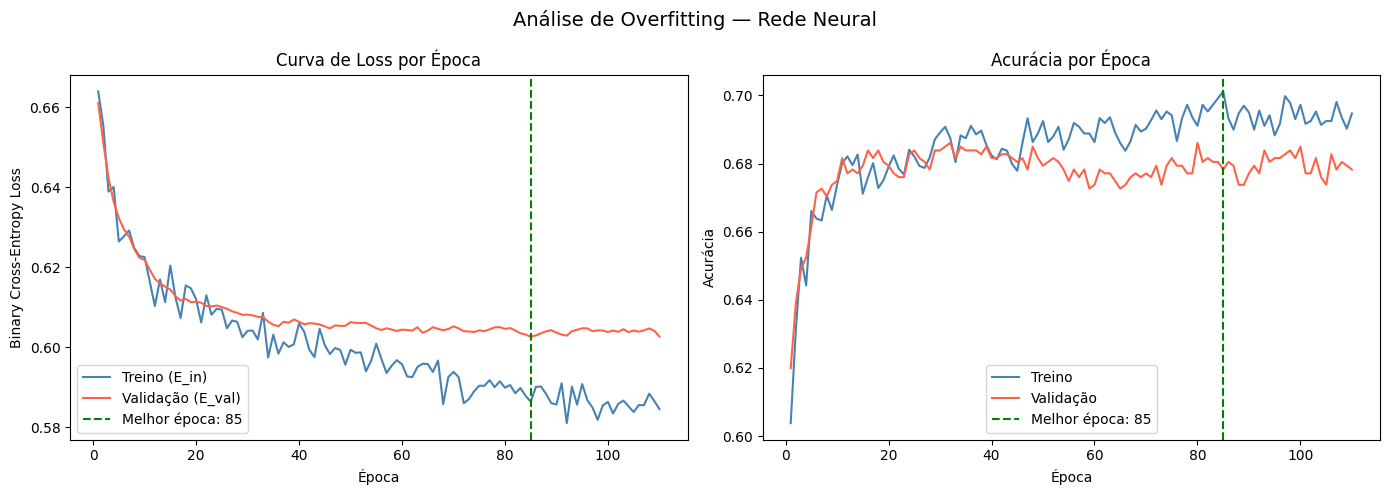

Melhor época (menor val_loss): 85 / 110


In [5]:
plot_overfitting_curve(history, save_path=str(FIGURES_DIR / '04_nn_overfitting.png'))

## 4.4 Métricas de Qualidade

E_in  (erro no treino): 0.3025  (30.25%)
E_out (erro no teste):  0.3348 (33.48%)
Gap E_out - E_in:       0.0323  (OK — sem overfitting)

Relatório de Classificação — Rede Neural
                 precision    recall  f1-score   support

Baixa Violência       0.68      0.64      0.65       557
 Alta Violência       0.66      0.69      0.67       557

       accuracy                           0.67      1114
      macro avg       0.67      0.67      0.66      1114
   weighted avg       0.67      0.67      0.66      1114



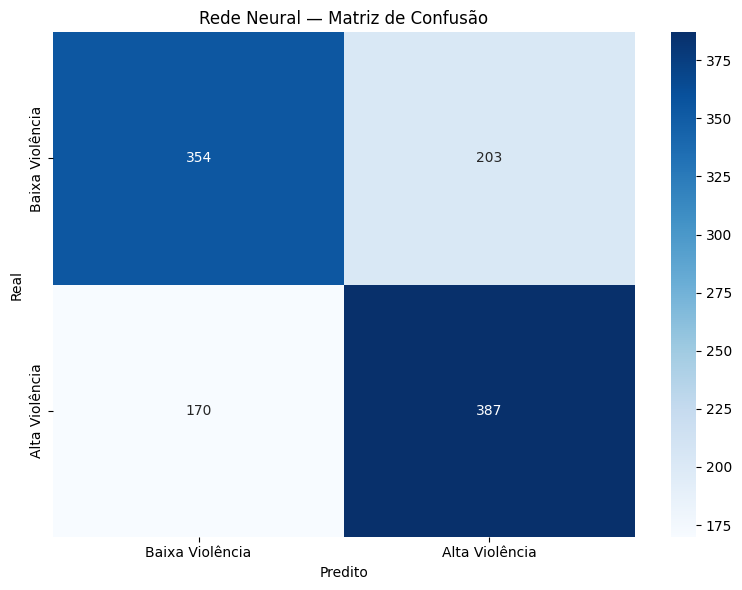


Métricas no conjunto de teste:
  accuracy: 0.6652
  precision: 0.6559
  recall: 0.6948
  f1_score: 0.6748


In [6]:
# E_in: calculado sobre X_train (4456 amostras — todos os dados de treino, incluindo val interna)
# Nota: a rede foi treinada em X_tr (3564), com X_val usado apenas para early stopping.
# Reportar E_in sobre X_train é o padrão do curso e representa o erro in-sample final.
y_train_pred = (model.predict(X_train, verbose=0) > 0.5).astype(int).ravel()
y_test_pred  = (model.predict(X_test,  verbose=0) > 0.5).astype(int).ravel()

from sklearn.metrics import accuracy_score
e_in  = 1 - accuracy_score(y_train, y_train_pred)
e_out = 1 - accuracy_score(y_test,  y_test_pred)
print(f"E_in  (erro no treino): {e_in:.4f}  ({e_in*100:.2f}%)")
print(f"E_out (erro no teste):  {e_out:.4f} ({e_out*100:.2f}%)")
print(f"Gap E_out - E_in:       {(e_out-e_in):.4f}  ({'overfitting' if e_out-e_in > 0.05 else 'OK — sem overfitting'})")

# Relatório completo
print_classification_report(y_test, y_test_pred, 'Rede Neural')

# Matriz de confusão
plot_confusion_matrix(y_test, y_test_pred, 'Rede Neural — Matriz de Confusão',
                      save_path=str(FIGURES_DIR / '04_nn_confusion.png'))

# Resumo das métricas
metrics = compute_metrics(y_test, y_test_pred)
print("\nMétricas no conjunto de teste:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

In [7]:
save_model(model, 'neural_network')
print("Modelo salvo em models/neural_network.joblib")

Modelo salvo em models/neural_network.joblib
